In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [3]:
uploaded = files.upload()

data = pd.read_csv("Iris.csv")

print(data.head())

Saving Iris.csv to Iris.csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
print("\nColumns (Features):", list(data.columns))
print("Number of Rows (Samples):", data.shape[0])
print("Target Variable: species")


Columns (Features): ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Number of Rows (Samples): 150
Target Variable: species


In [10]:
label_encoder = LabelEncoder()
data['species_encoded'] = label_encoder.fit_transform(data['Species'])
print("\nClass labels after encoding:")
print(data[['Species', 'species_encoded']].drop_duplicates())


Class labels after encoding:
             Species  species_encoded
0        Iris-setosa                0
50   Iris-versicolor                1
100   Iris-virginica                2


In [11]:
print(data.isnull().sum())

# Use MEDIAN since we have used mean for KNN
data.fillna(data.median(numeric_only=True), inplace=True)

Id                 0
SepalLengthCm      0
SepalWidthCm       0
PetalLengthCm      0
PetalWidthCm       0
Species            0
species_encoded    0
dtype: int64


In [12]:
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data['species_encoded']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [14]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [15]:
sample = X_test.iloc[[0]]

probs = nb.predict_proba(sample)

print("Sample:")
print(sample)

print("\nClass Probabilities:")
for i, prob in enumerate(probs[0]):
    print(f"{label_encoder.inverse_transform([i])[0]}: {prob:.4f}")

print("\nPredicted Class:", label_encoder.inverse_transform(nb.predict(sample))[0])

Sample:
    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
38            4.4           3.0            1.3           0.2

Class Probabilities:
Iris-setosa: 1.0000
Iris-versicolor: 0.0000
Iris-virginica: 0.0000

Predicted Class: Iris-setosa


In [16]:
# Training performance
y_train_pred = nb.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='macro')
train_rec = recall_score(y_train, y_train_pred, average='macro')

print("Training Performance:")
print(f"Accuracy: {train_acc:.2f}, Precision: {train_prec:.2f}, Recall: {train_rec:.2f}")

# Testing performance
y_test_pred = nb.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='macro')
test_rec = recall_score(y_test, y_test_pred, average='macro')

print("\nTesting Performance:")
print(f"Accuracy: {test_acc:.2f}, Precision: {test_prec:.2f}, Recall: {test_rec:.2f}")

Training Performance:
Accuracy: 0.96, Precision: 0.96, Recall: 0.96

Testing Performance:
Accuracy: 0.97, Precision: 0.97, Recall: 0.97


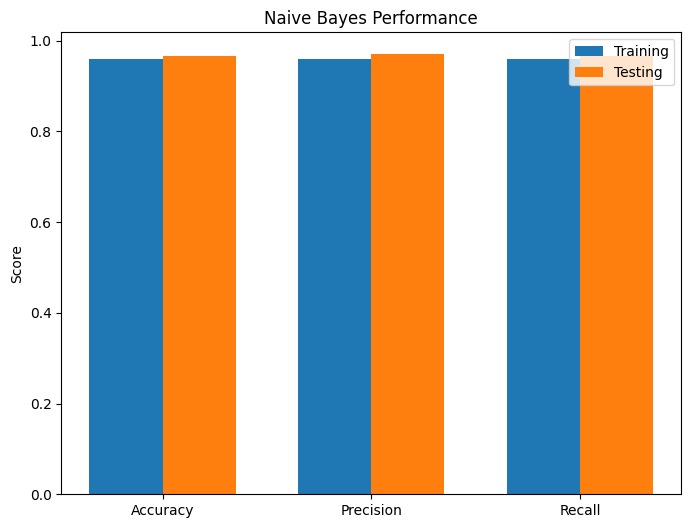

In [17]:
metrics = ['Accuracy', 'Precision', 'Recall']
training_scores = [train_acc, train_prec, train_rec]
testing_scores = [test_acc, test_prec, test_rec]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x - width/2, training_scores, width, label='Training')
ax.bar(x + width/2, testing_scores, width, label='Testing')

ax.set_ylabel('Score')
ax.set_title('Naive Bayes Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

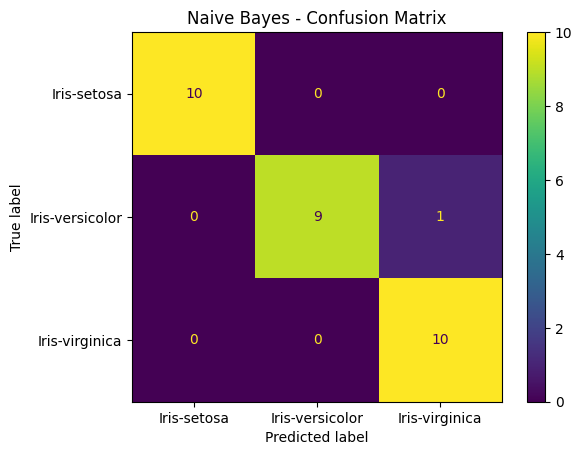

In [18]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [19]:
new_sample = pd.DataFrame([[5.0, 3.5, 1.4, 0.2]],
                          columns=X.columns)

prediction = nb.predict(new_sample)[0]
predicted_class = label_encoder.inverse_transform([prediction])[0]

print("New Sample:", new_sample.values)
print("Predicted class:", predicted_class)

New Sample: [[5.  3.5 1.4 0.2]]
Predicted class: Iris-setosa
